# Potato Blight Classification

**by Group 1**


---

## 1: Business Understanding

### 1.1 Business Context

Potato farming is one of the most economically significant agricultural activities in Sub-Saharan Africa, South Asia, and Latin America, where smallholder farmers depend on potato yields for both subsistence and income. However, potato crops are highly vulnerable to fungal diseases — most notably **Early Blight** (*Alternaria solani*) and **Late Blight** (*Phytophthora infestans*). Left undetected, these diseases can devastate 30–70% of a crop, causing severe food insecurity and financial loss.

Traditional disease identification relies on experts conducting in-person field inspections — a resource that most smallholder farmers cannot access in time. By the point visible symptoms have spread, the window for effective treatment is often already closed.

This project builds an **automated potato blight classification system** using the PlantVillage dataset and a MobileNetV2 deep learning architecture. The model classifies leaf images into three categories — **Early Blight**, **Late Blight**, and **Healthy** — enabling rapid, low-cost diagnosis directly from a smartphone photo.


### 1.2 Stakeholders

| Stakeholder | Interest |
|---|---|
| **Smallholder Farmers** | Early, accurate disease diagnosis to protect yield and income |
| **Agricultural Officers** | A scalable tool to assist field services |
| **NGOs & Food Security Bodies** | Reduction of crop loss in vulnerable communities |
| **Data / ML Teams** | Reproducible, maintainable model pipeline |

### 1.3 Project Plan (CRISP-DM Phases)

```
Phase 1: Business Understanding
Phase 2: Data Understanding
Phase 3: Data Preparation
Phase 4: Modeling
Phase 5: Evaluation
Phase 6: Deployment
```

**Deliverables:**
- Jupyter Notebook 
- GitHub Repository
- Deployment
- Non-Technical Presentation

---

## 2: Data Understanding

### 2.1 Overview — PlantVillage Potato Subset

The dataset is sourced from the **PlantVillage** project, a large-scale open dataset of plant leaf imagery developed at Penn State University. The full PlantVillage dataset covers 38 disease classes across 14 crop species; this project uses the **potato subset only**, consisting of 2,152 images across three classes.

| Class Folder | Disease | Images (approx.) | Share |
|---|---|---|---|
| `Potato___Early_blight` | *Alternaria solani* fungal infection | 1,000 | ~46 % |
| `Potato___Late_blight` | *Phytophthora infestans* water mould | 1,000 | ~46 % |
| `Potato___healthy` | No visible disease | 152 | ~7 % |



### 2.2 Import Libraries

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries

import os
import cv2
import PIL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import matplotlib.cm as cm
from PIL import Image


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import (
    layers, Model, Sequential
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow  : {tf.__version__}')
print(f'GPUs visible: {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow  : 2.21.0
GPUs visible: 0


### 2.3 Configuration

In [3]:
# for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyper-parameters 
IMG_SIZE    = 224          # MobileNetV2 expects 224×224
BATCH_SIZE  = 32
EPOCHS_HEAD = 15           # train only the new head
EPOCHS_FINE = 20           # fine-tune top layers of base
LR_HEAD     = 1e-3
LR_FINE     = 5e-5
UNFREEZE_FROM = 130        # unfreeze MobileNetV2 layers from this index onward

CLASS_NAMES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_NAMES)}
DISPLAY_NAMES = ['Early Blight', 'Late Blight', 'Healthy']


DATASET_DIR = 'PlantVillage'  
CHECKPOINT_PATH = 'best_potato_model.h5'

### 2.4 Class Distribution

In [4]:
def count_images(dataset_dir, class_names):
    records = []
    for cls in class_names:
        cls_path = os.path.join(dataset_dir, cls)
        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        records.append({
            'class':   cls,
            'display': DISPLAY_NAMES[CLASS_NAMES.index(cls)],
            'count':   len(files)
        })
    return pd.DataFrame(records)

dist_df = count_images(DATASET_DIR, CLASS_NAMES)
dist_df['pct'] = (dist_df['count'] / dist_df['count'].sum() * 100).round(1)
print(dist_df[['display', 'count', 'pct']].to_string(index=False))
print(f"\nTotal images: {dist_df['count'].sum()}")

     display  count  pct
Early Blight   1000 46.5
 Late Blight   1000 46.5
     Healthy    152  7.1

Total images: 2152


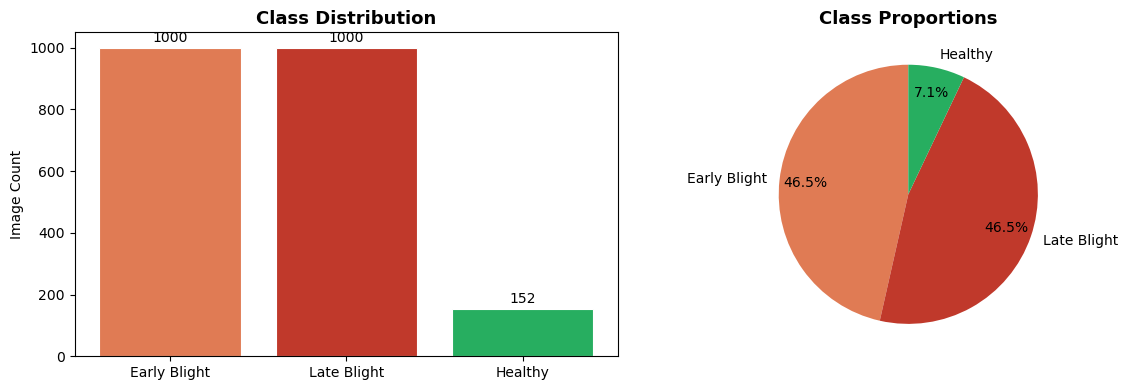

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e07b54', '#c0392b', '#27ae60']

axes[0].bar(dist_df['display'], dist_df['count'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Image Count')
for bar, cnt in zip(axes[0].patches, dist_df['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(cnt), ha='center', va='bottom', fontsize=10)

axes[1].pie(dist_df['count'], labels=dist_df['display'], colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights**

`Class Imbalance:` The healthy class accounts for only ~7% of the dataset. Without corrective measures (class weighting), a naive model could achieve ~93% accuracy by simply predicting disease every time — while entirely failing to identify healthy plants. This is why Macro F1 is the primary metric.


### 2.5 Sample Image Grid

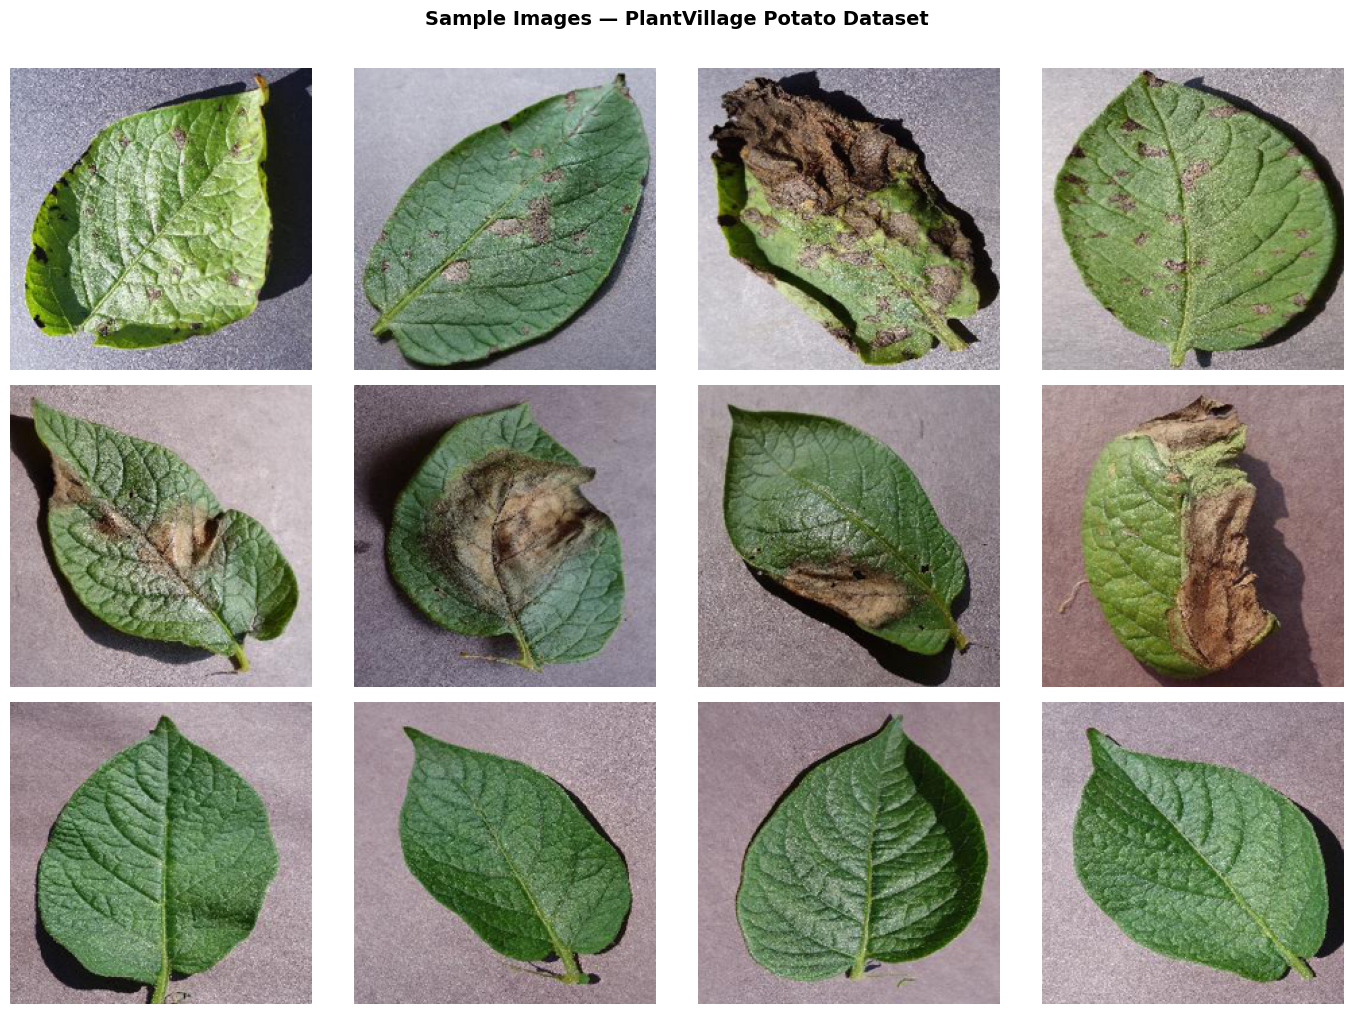

In [6]:
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Images — PlantVillage Potato Dataset', fontsize=14, fontweight='bold', y=1.01)

for row, (cls, dname) in enumerate(zip(CLASS_NAMES, DISPLAY_NAMES)):
    cls_dir = os.path.join(DATASET_DIR, cls)
    samples = np.random.choice(os.listdir(cls_dir), 4, replace=False)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_dir, fname)).resize((224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(dname, fontsize=11, fontweight='bold', rotation=0,
                                      labelpad=80, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3: Data Preparation

### 3.1 Build File List & Stratified Split

In [7]:
def build_file_list(dataset_dir, class_names):
    """Return (paths, labels) arrays with integer label encoding."""
    paths, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(dataset_dir, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(LABEL_MAP[cls])
    return np.array(paths), np.array(labels)
all_paths, all_labels = build_file_list(DATASET_DIR, CLASS_NAMES)
print(f'Total files loaded: {len(all_paths)}')
# Stratified split: 70 % train / 15 % val / 15 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, 
random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f'Train : {len(X_train)} images')
print(f'Val   : {len(X_val)}  images')
print(f'Test  : {len(X_test)}  images')

Total files loaded: 2152
Train : 1506 images
Val   : 323  images
Test  : 323  images


`Why stratified splits?` Stratification ensures each split preserves the original class
proportions. 

Without it, the rare healthy class (only ~152 images) could be randomly
absent or over-concentrated in one split, making validation metrics unreliable.

### 3.2. Class Weights

In [8]:
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

**Interpretation:** `compute_class_weight('balanced', ...)` assigns each class a weightinversely proportional to its frequency. The healthy class will receive a much higherweight (~6–7×) than the disease classes, penalising the model more heavily formisclassifying the rare class during training.


### 3.3. tf.data Pipeline

In [9]:

AUTOTUNE = tf.data.experimental.AUTOTUNE
def load_and_preprocess_image(path, label):
    """Read image, resize, scale to [-1, 1]"""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label
    
def augment(image, label):
    """Augmentation applied only during training"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.05)
    frac     = tf.random.uniform([], 0.85, 1.0)
    crop_sz  = tf.cast(tf.cast(IMG_SIZE, tf.float32) * frac, tf.int32)
    image    = tf.image.random_crop(image, [crop_sz, crop_sz, 3])
    image    = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image    = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

def make_dataset(paths, labels, augment_flag=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds
# ds.shuffle shuffles the order of images (training only)
# ds.map reads each image file, resizes to 224x224, scales pixel values to [-1, 1]
# augment applies random flips, brightness, crop etc. (training only)
# ds.batch roups images into batches of 32
# prefetch loads the next batch in the background while the model trains on the current one

train_ds = make_dataset(X_train, y_train, augment_flag=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   augment_flag=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment_flag=False, shuffle=False)
print('Datasets ready.')
for images, labels in train_ds.take(1):
    print(f'  Batch shape: {images.shape}, label dtype: {labels.dtype}')



Datasets ready.
  Batch shape: (32, 224, 224, 3), label dtype: <dtype: 'int64'>


**Augmentation rationale**: With only 2,152 images, the training set is small enough that
overfitting is a real risk. The augmentation pipeline applies a range of realistic
photometric and geometric transforms (flips, brightness shifts, saturation changes,
random crop) to synthetically expand training diversity. Augmentation is applied only to
the training set — validation and test sets always use the clean, unmodified images to
ensure the evaluation reflects real-world deployment conditions.

---
## 4: Modeling

### 4.1 Architecture Overview — Transfer Learning with MobileNetV2

Rather than training a CNN from scratch (which would require far more data), this project uses **transfer learning**: a MobileNetV2 model pre-trained on ImageNet is used as a feature extractor, and a custom classification head is attached on top.

**Why MobileNetV2?**
- Designed to be computationally efficient, making it suitable for deployment on edge devices (smartphones, used by farmers in the field)
- The depthwise separable convolutions in MobileNetV2 capture rich spatial features with fewer parameters than standard convolutions
- ImageNet pre-training encodes general visual features (edges, textures, shapes) that transfer well to leaf imagery

**Two-phase training strategy:**

| Phase | Base model | Learning rate | Purpose |
|---|---|---|---|
| Phase 1 (Head training) | Frozen | 1e-3 | Train the new classification head only; avoids corrupting ImageNet weights with a large gradient |
| Phase 2 (Fine-tuning) | Top layers unfrozen (from layer 130+) | 5e-5 | Gently adapt the upper convolutional blocks to potato leaf features while preserving low-level features |


`***Overview of the CNN process in Computer Vision:***`

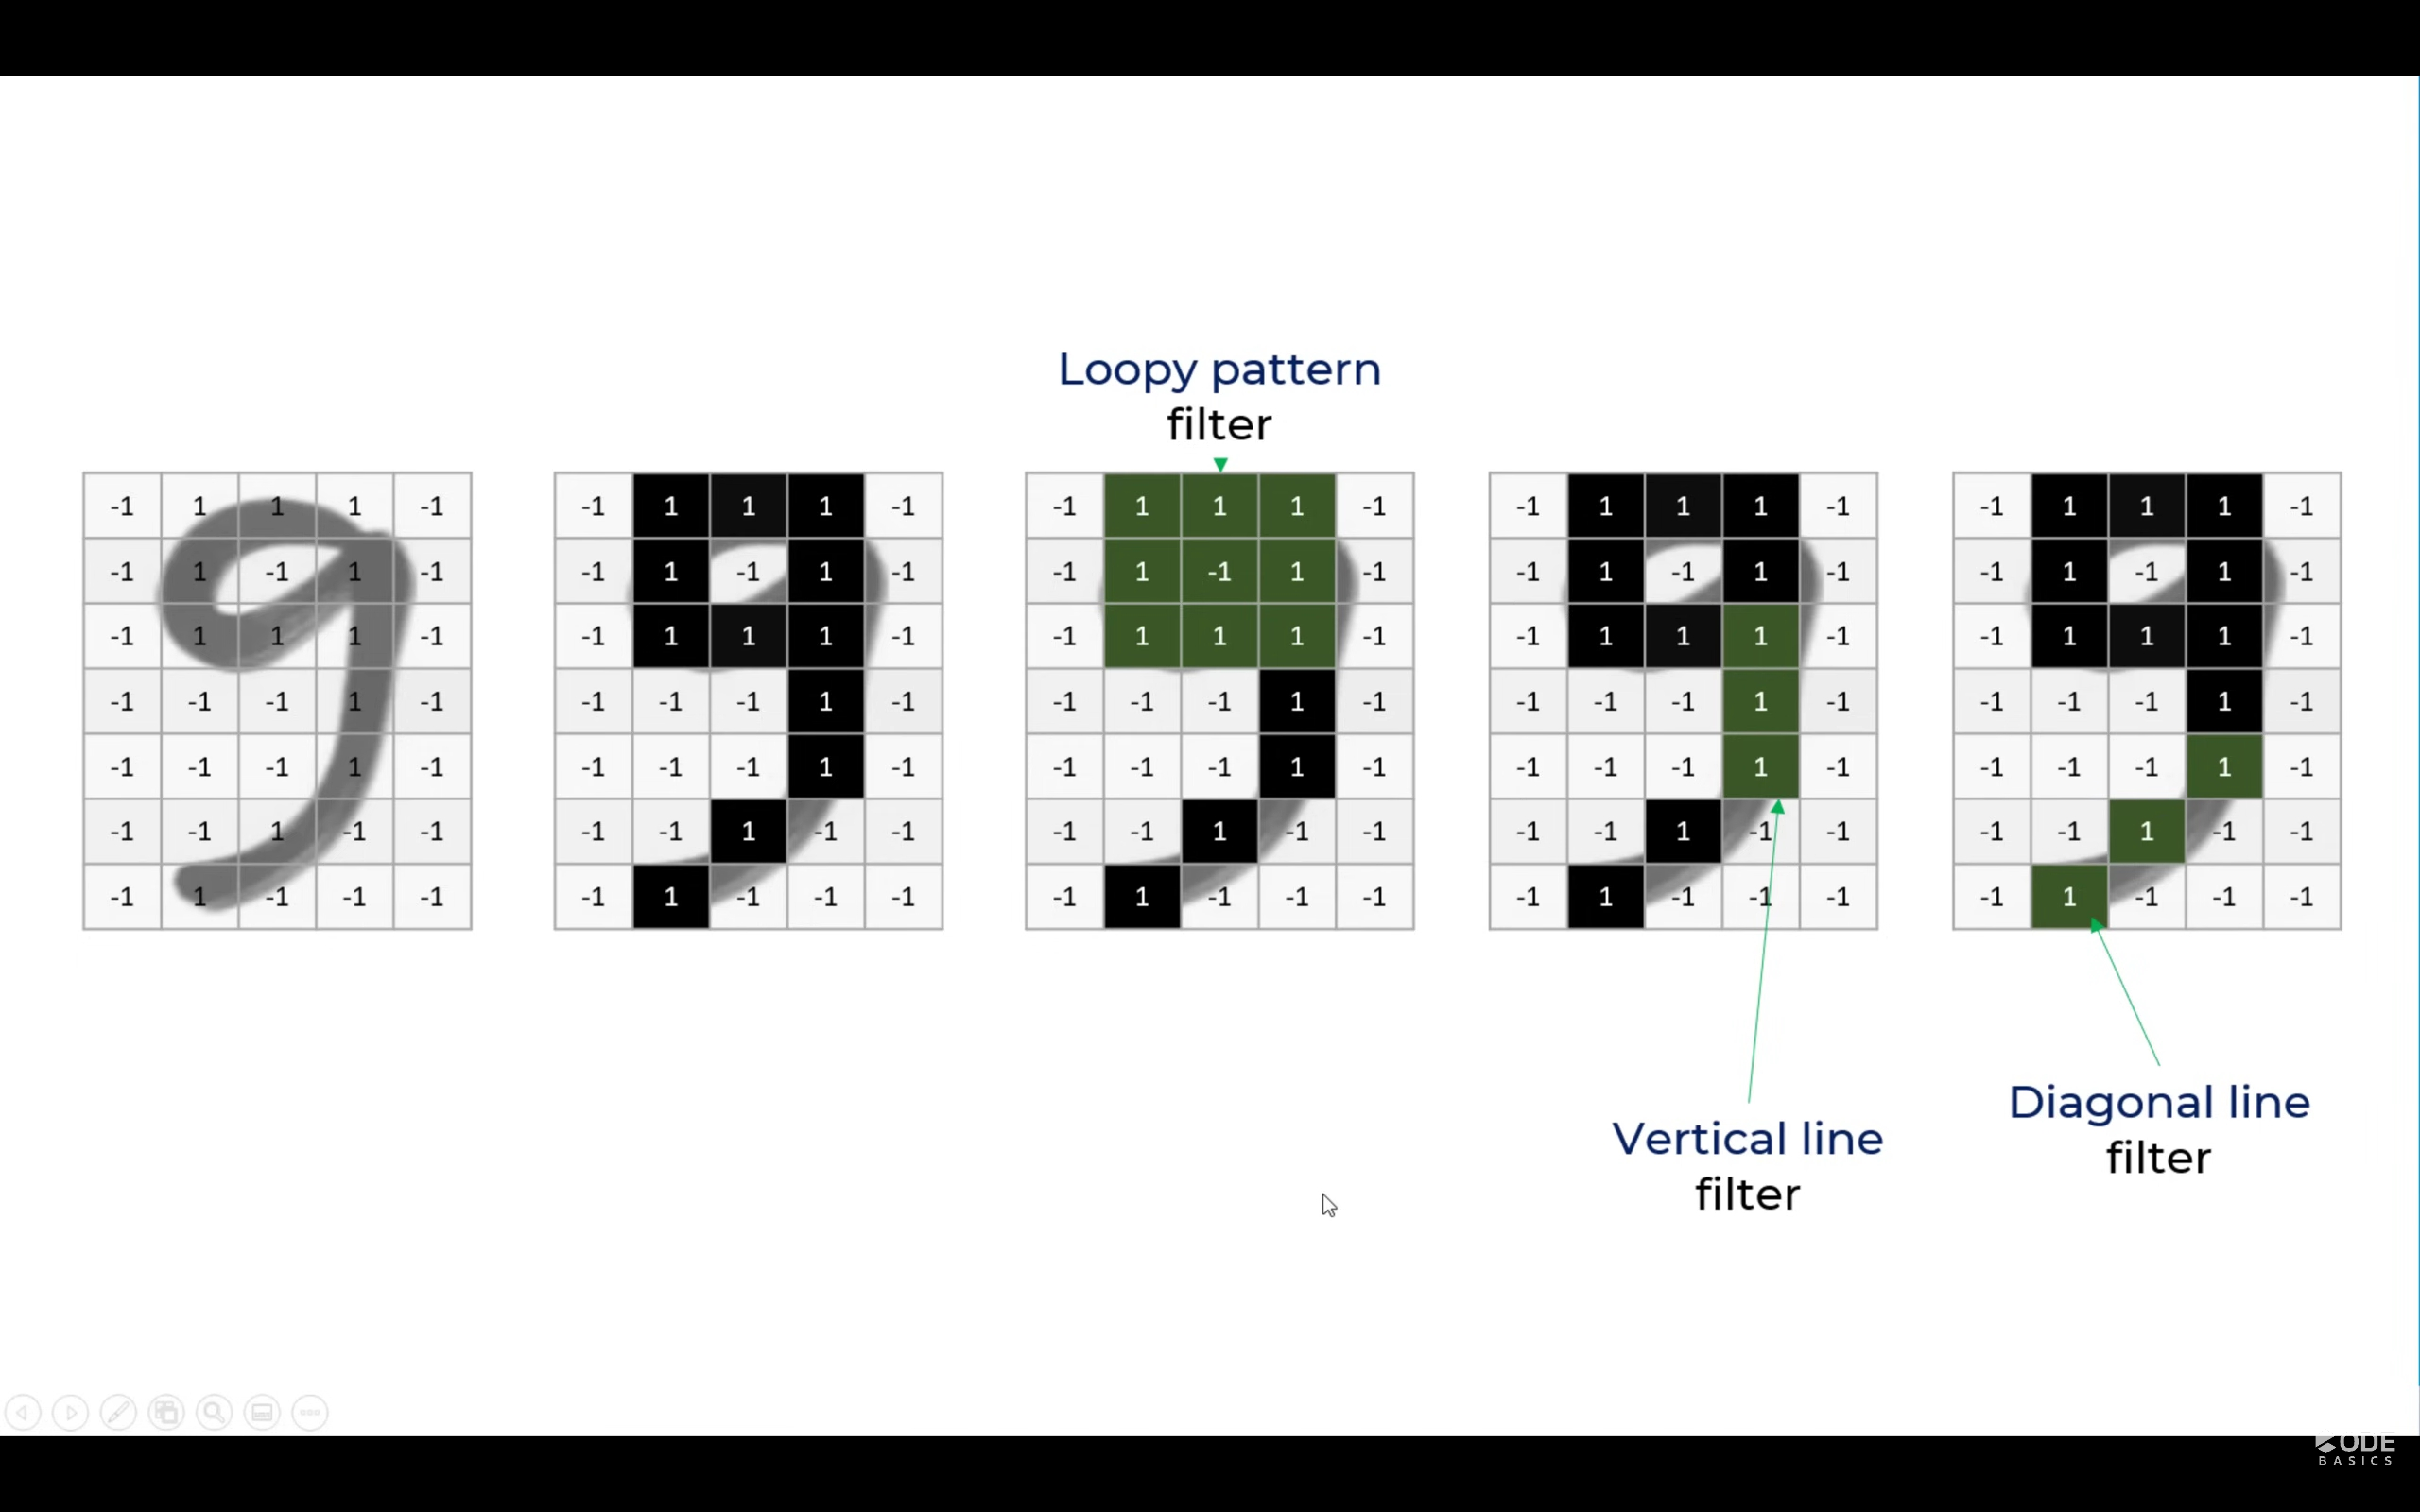

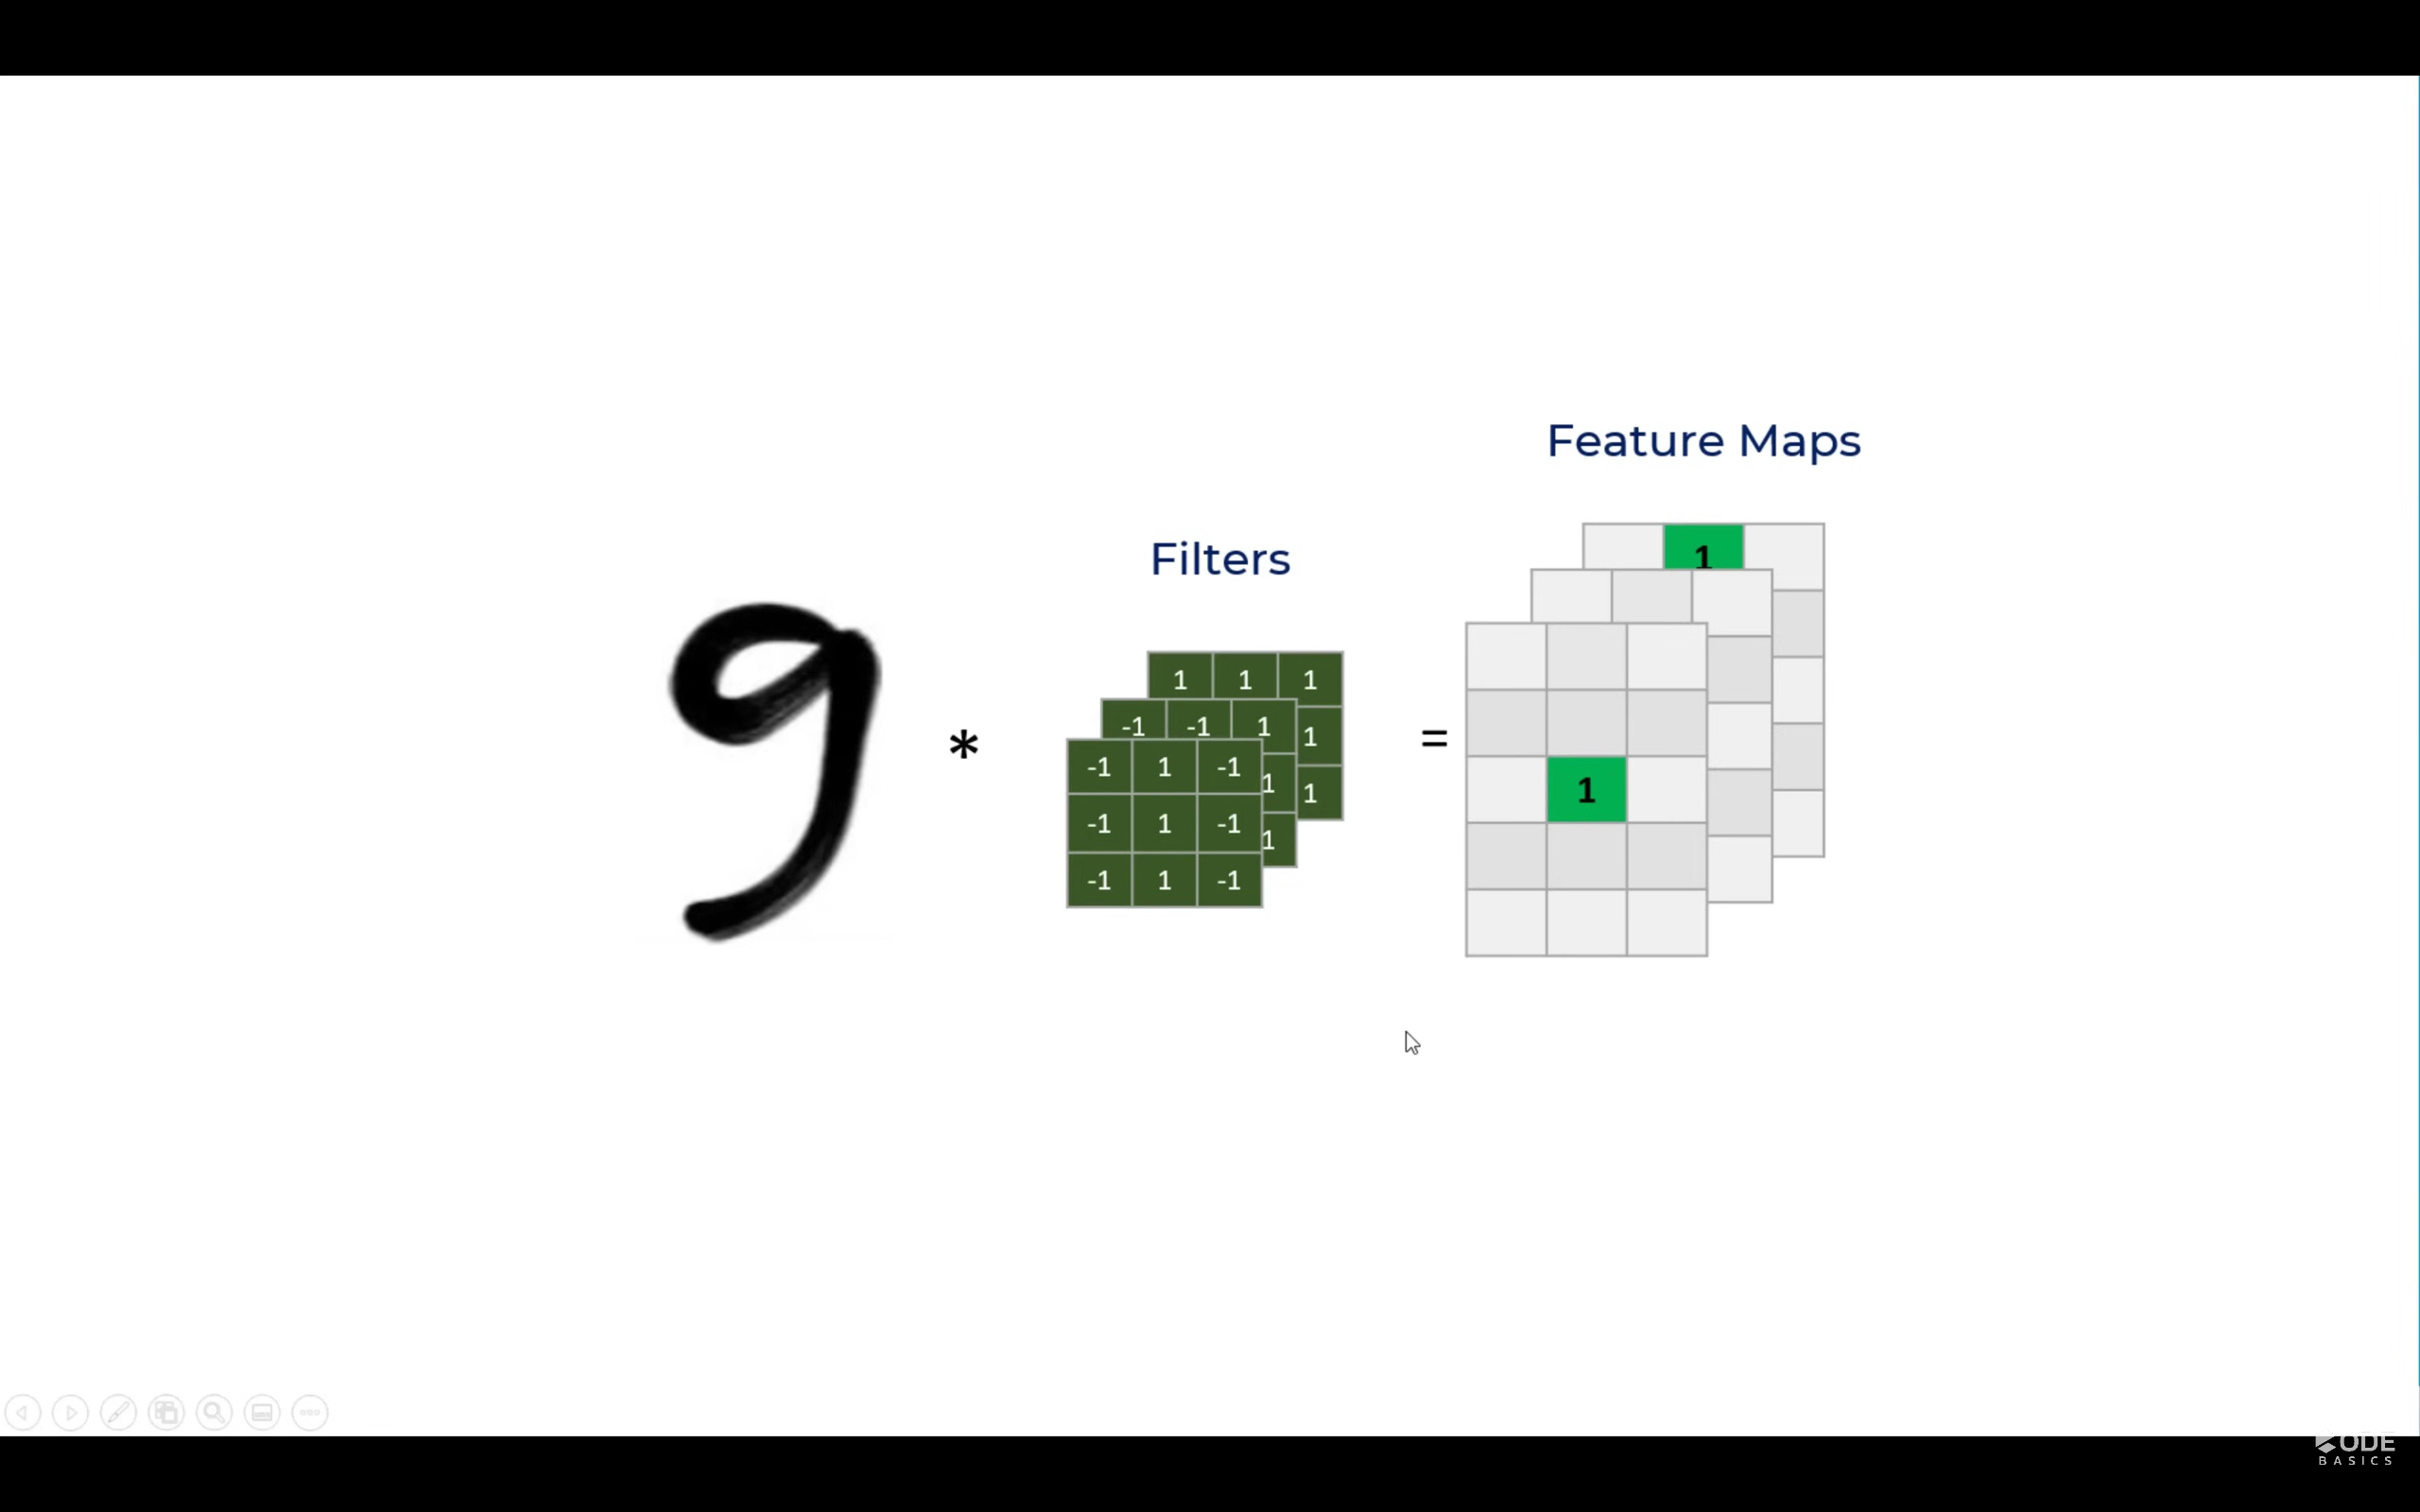

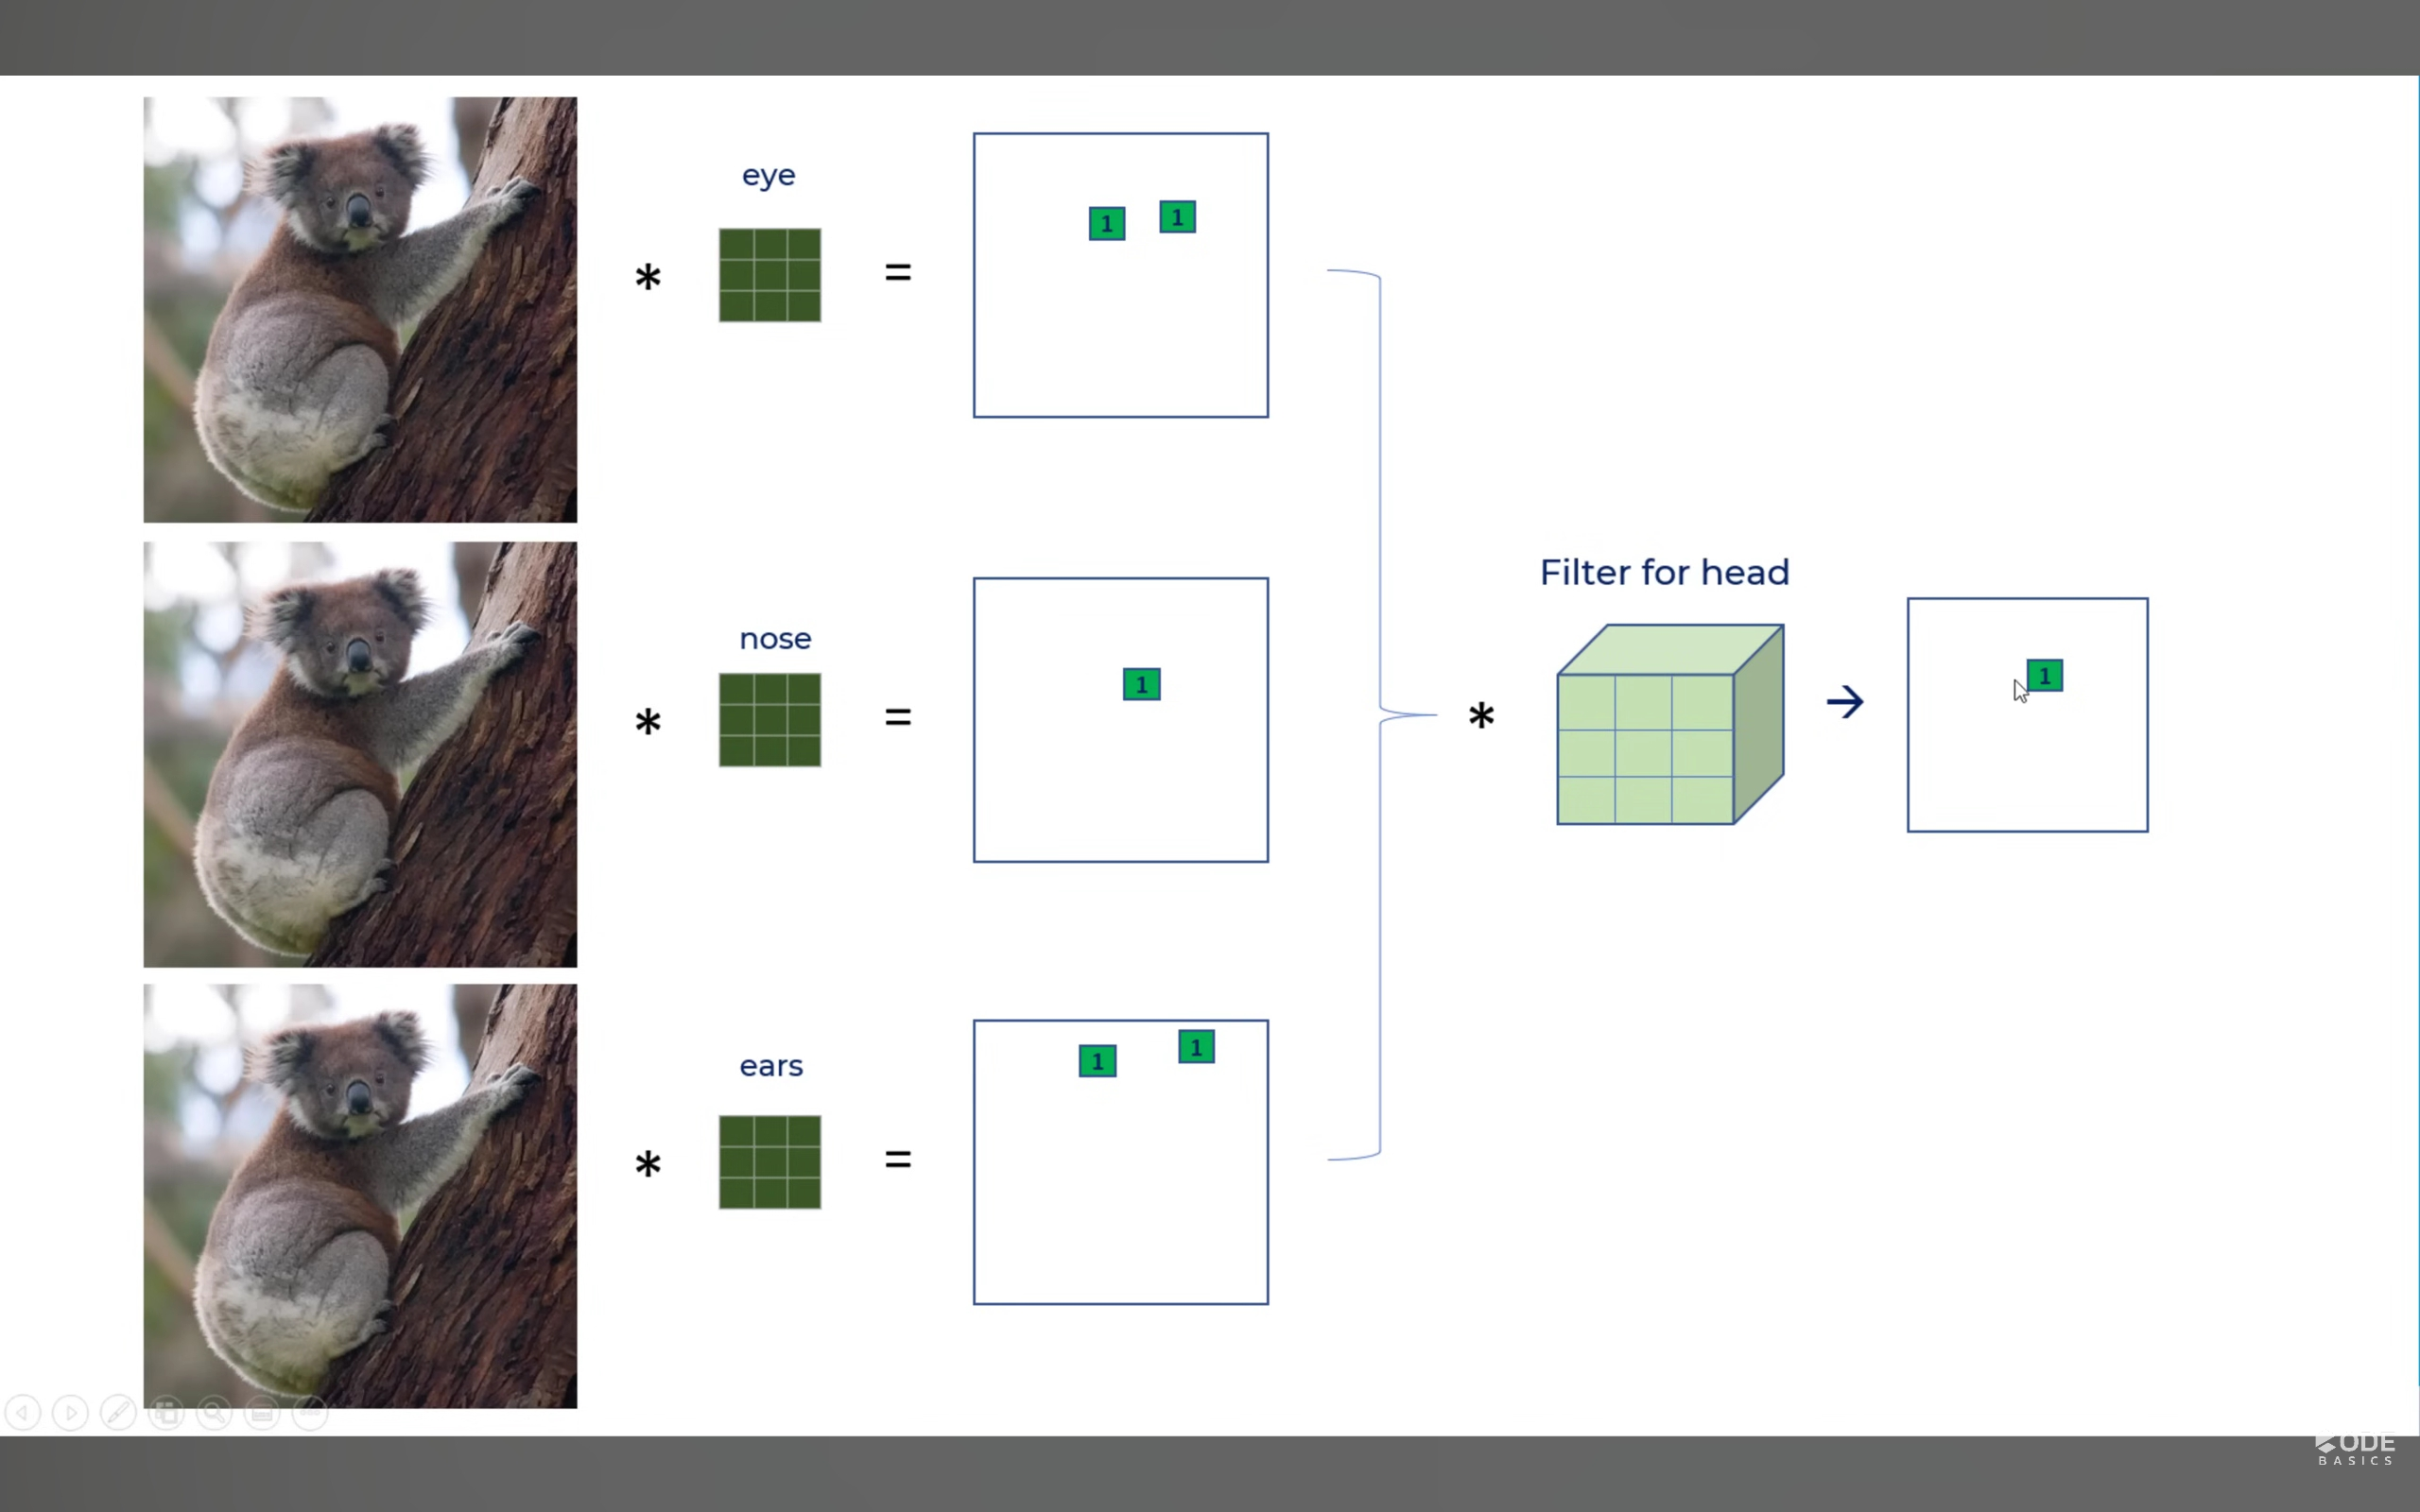

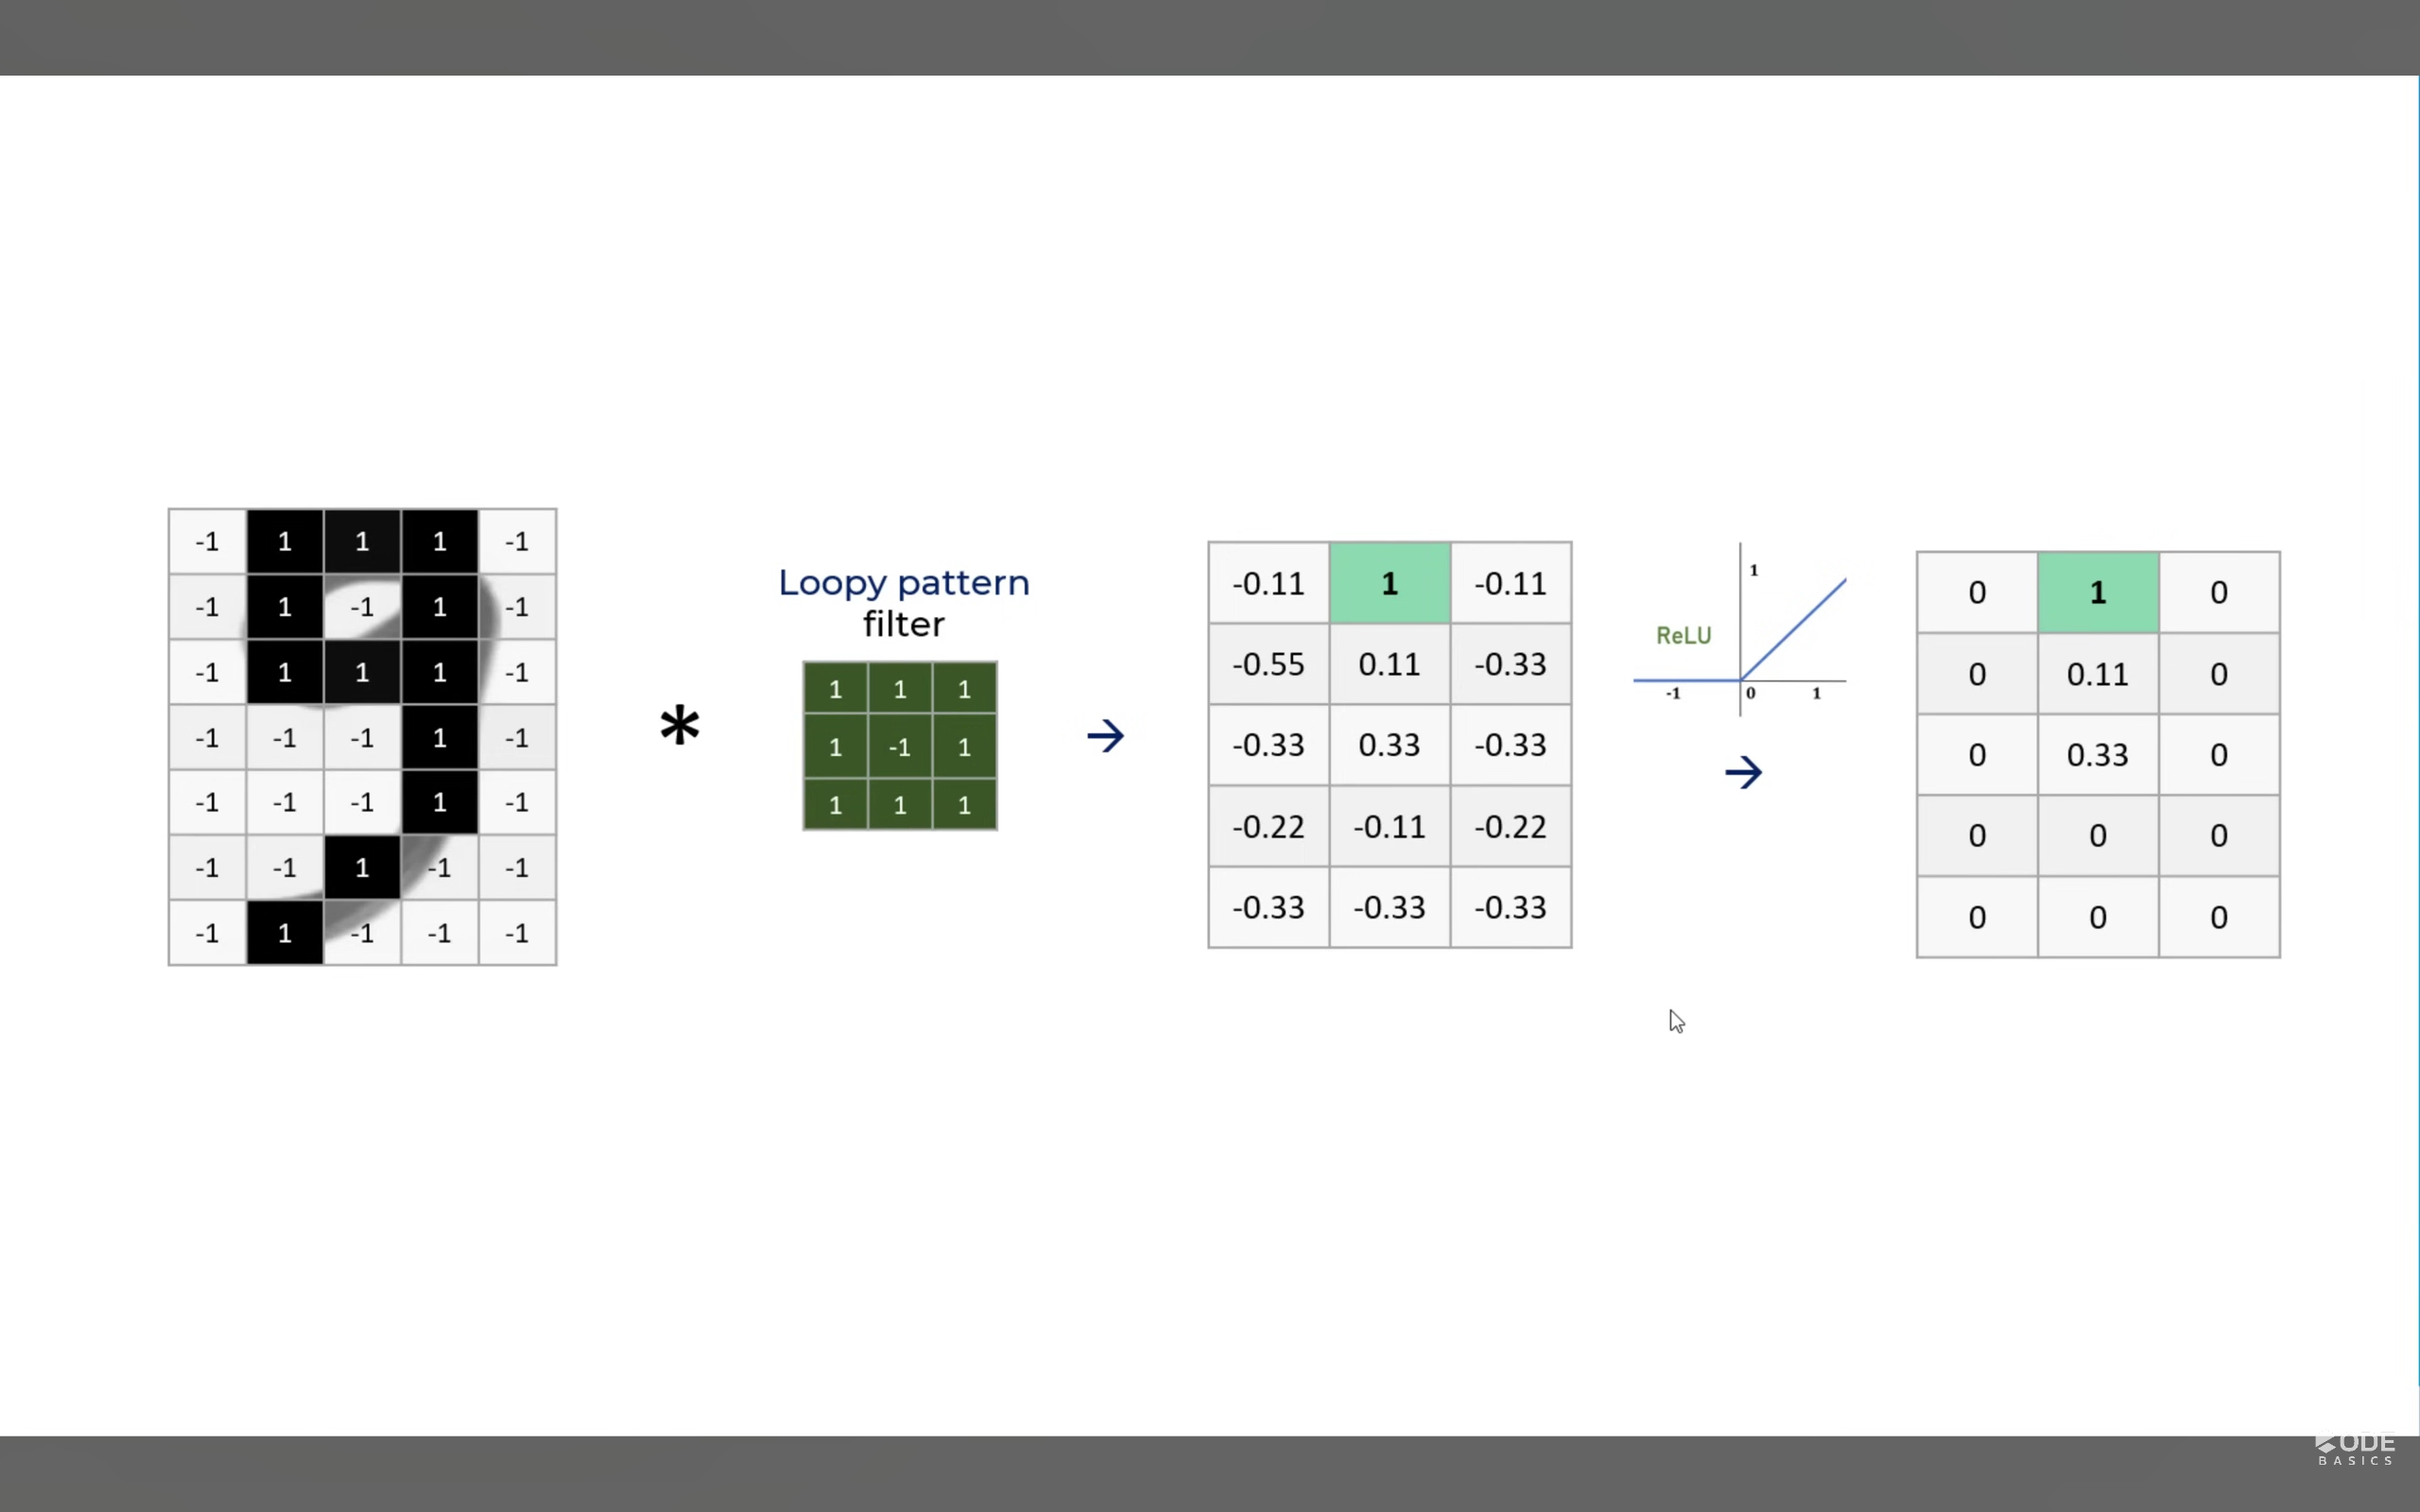

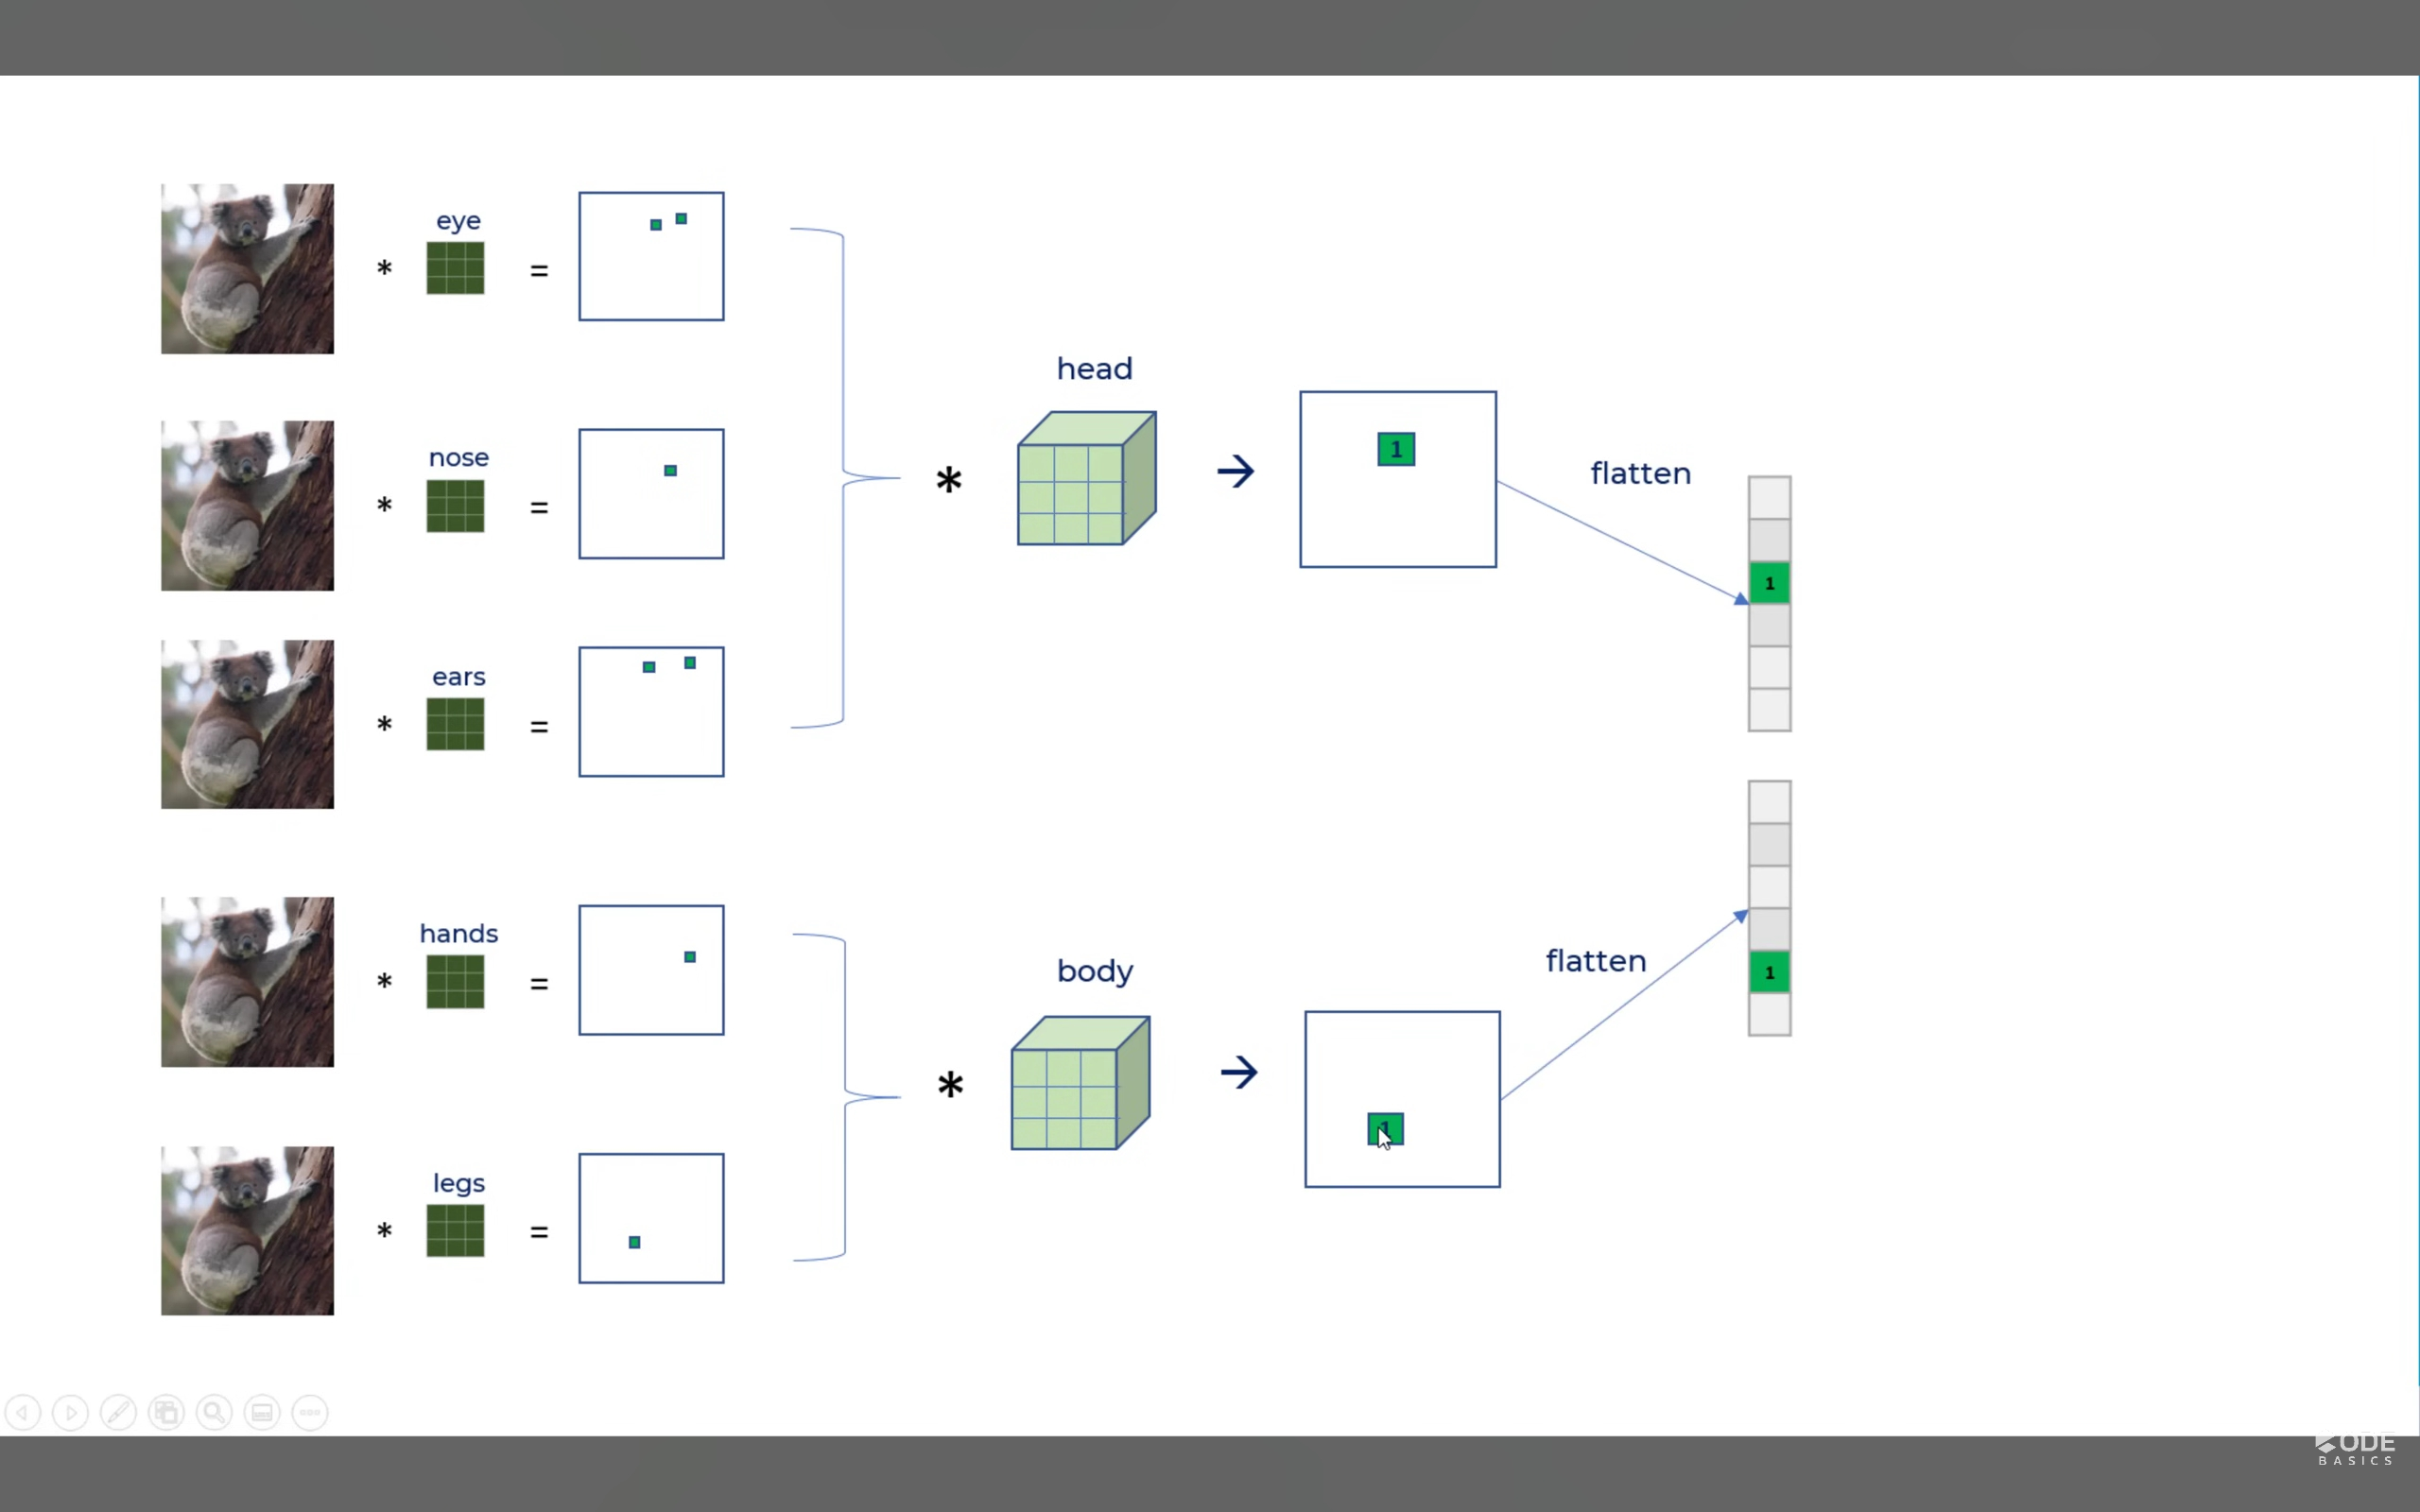

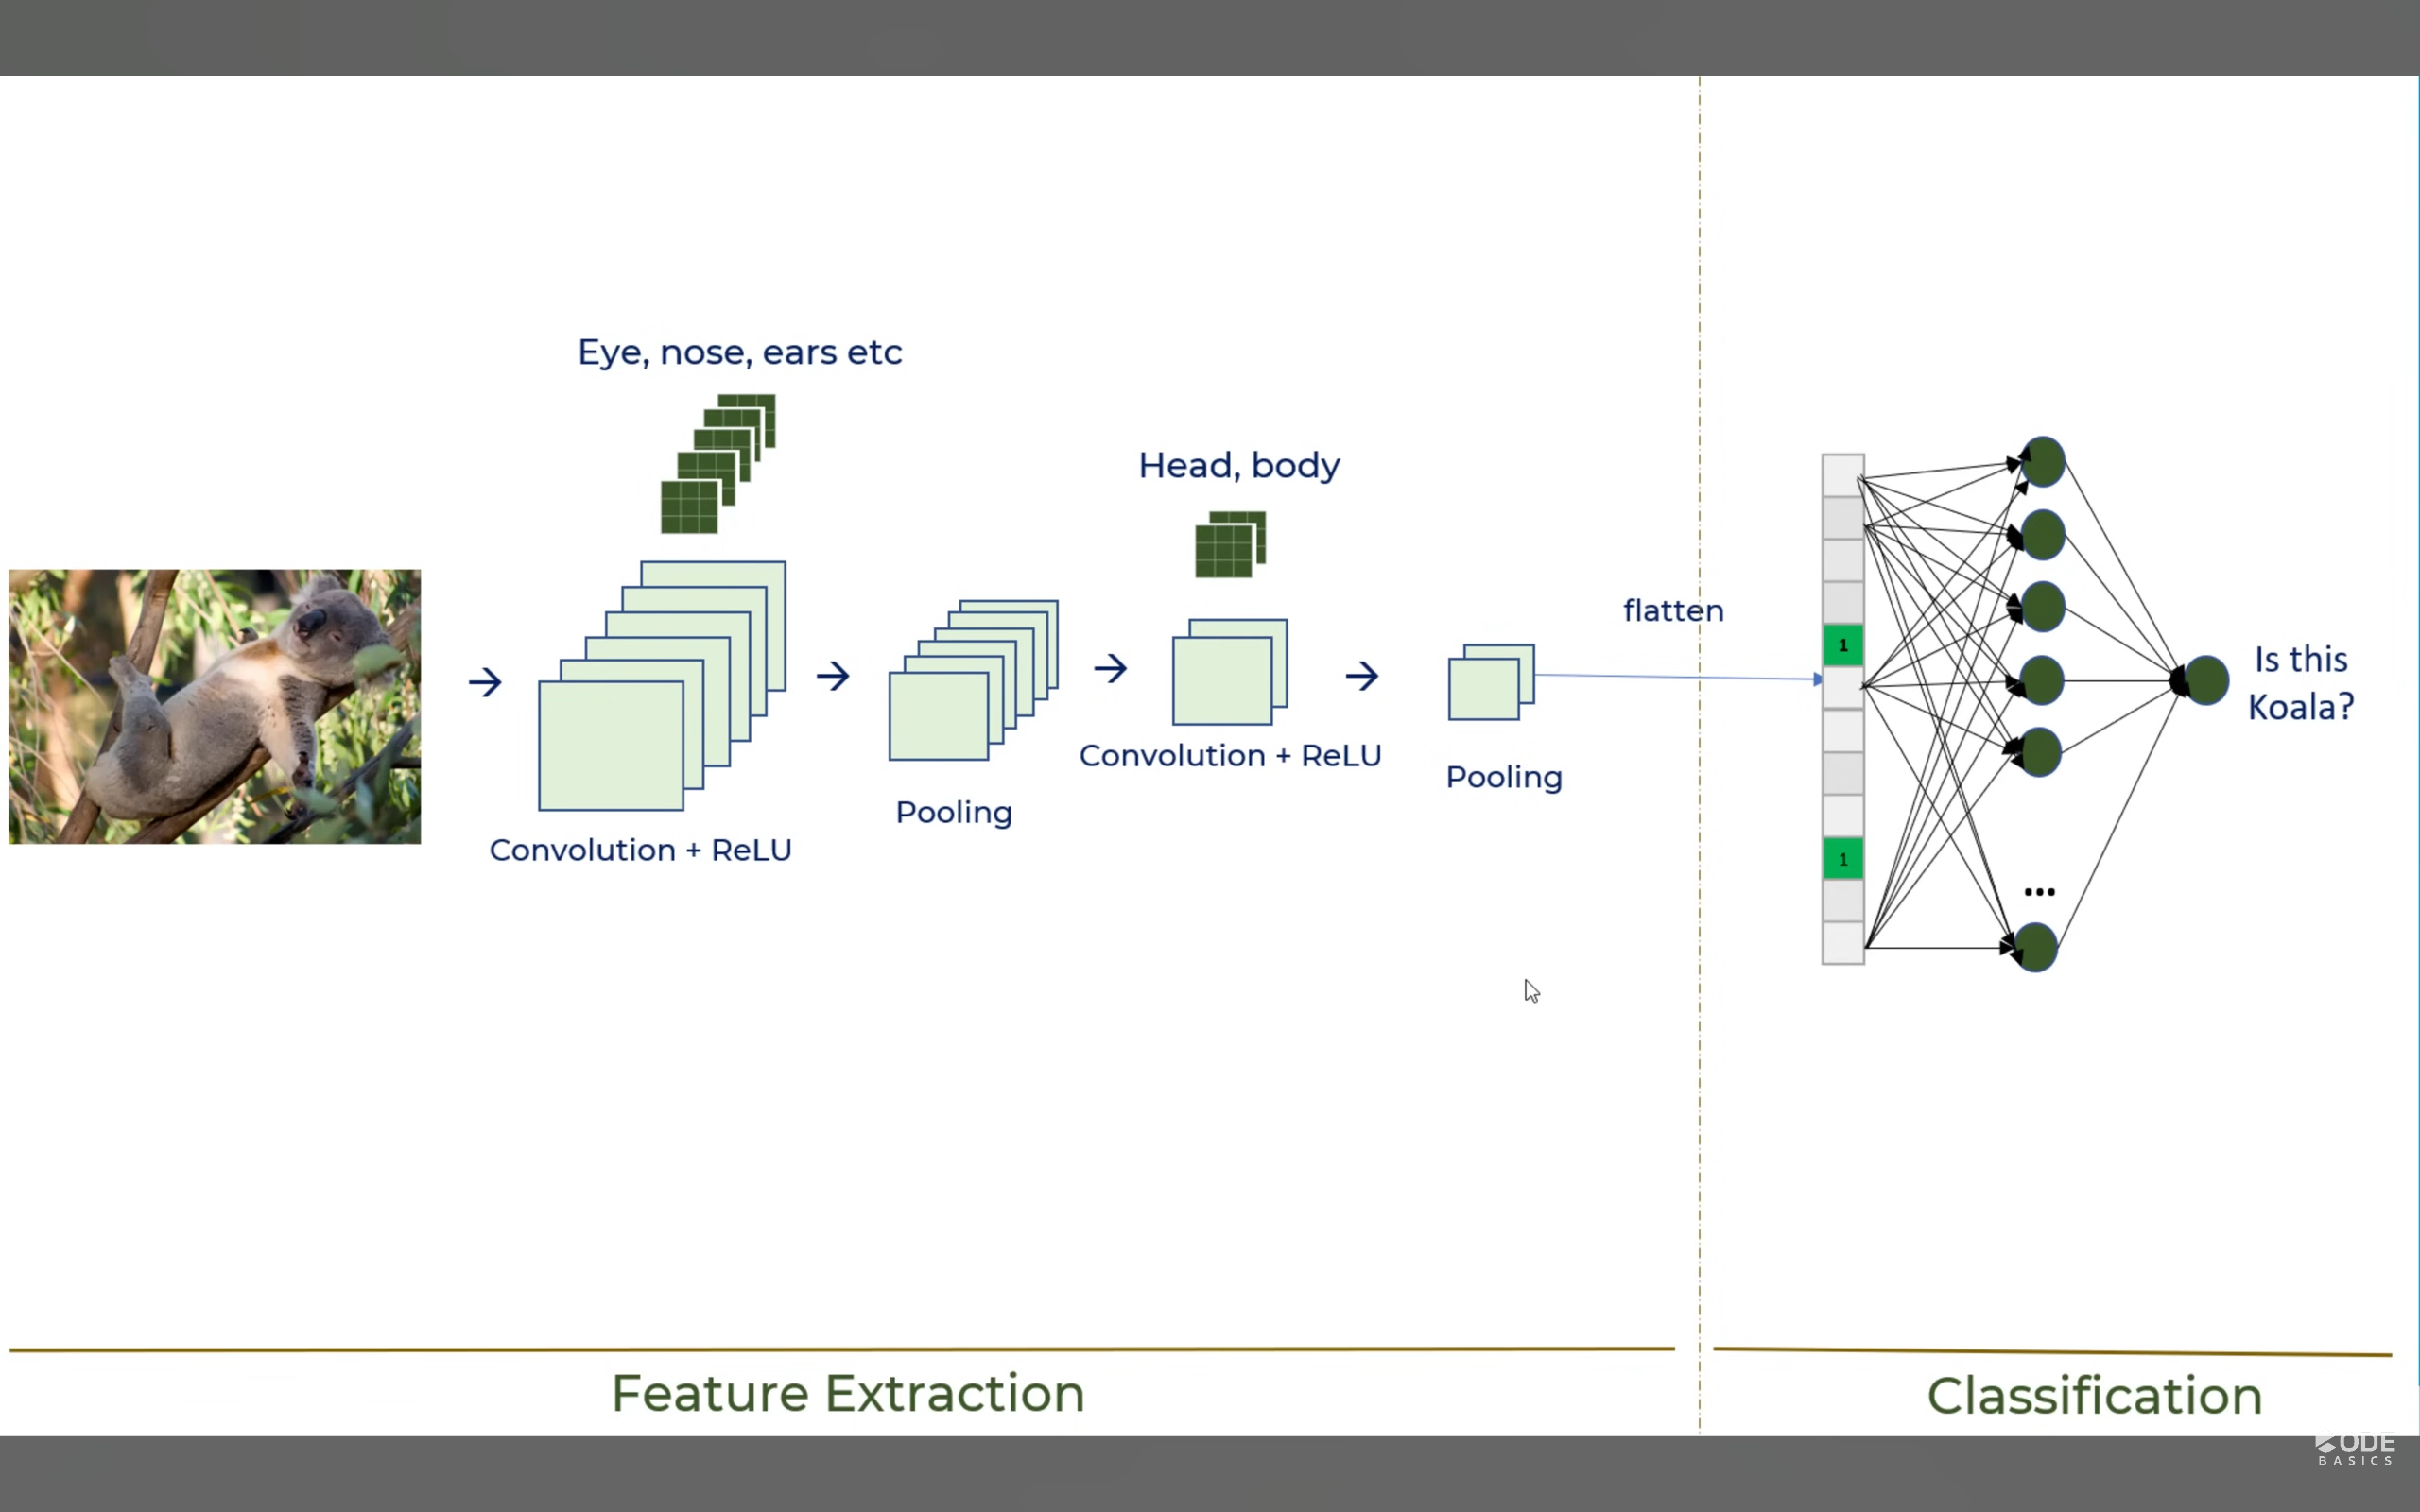

In [10]:
from IPython.display import Image, display

display(Image(filename='assets/filters.jpg'))
display(Image(filename='assets/feature_maps.jpg'))
display(Image(filename='assets/head_feature_map.jpg'))
display(Image(filename='assets/ReLu.jpg'))
display(Image(filename='assets/flattening.jpg'))
display(Image(filename='assets/CNN_process.jpg'))

### 4.2 Build Model

In [11]:
def build_model(num_classes=3, trainable_base=False):
    # Base: MobileNetV2 pretrained on ImageNet
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    # Classification head 
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base

model, base_model = build_model(num_classes=3, trainable_base=False)
model.summary(line_length=90)

trainable   = sum(np.prod(v.shape) for v in model.trainable_variables)
untrainable = sum(np.prod(v.shape) for v in model.non_trainable_variables)
print(f'\nTrainable params    : {trainable:,}')
print(f'Non-trainable params: {untrainable:,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d              │ (None, 1280)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 1280)                 │           5,120 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 128)                  │          32,896 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                       │ (None, 3)                    │             387 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Trainable params    : 363,779
Non-trainable params: 2,260,548


**Head design choices:**

- `GlobalAveragePooling2D` reduces the spatial feature map from the base to a single vector, avoiding the large flatten layer that would otherwise dramatically increase parameter count.
- `BatchNormalization` stabilises training after the frozen base and before the dense layers.
- Two dense layers (256 → 128) with `L2 regularisation` and `Dropout` provide capacity to learn disease-discriminative patterns while resisting overfitting on the small dataset.


### 4.3 Custom Macro F1 Metric

In [14]:
class MacroF1Score(keras.metrics.Metric):
    """Macro-averaged F1 score tracked per batch accumulation."""

    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_cls = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        # TF 2.3 passes y_true as (batch, 1) for sparse CE; flatten to (batch,)
        # so one_hot produces (batch, C) not (batch, 1, C).
        y_true_i32 = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred_oh  = tf.one_hot(y_pred_cls, self.num_classes)   # (batch, C)
        y_true_oh  = tf.one_hot(y_true_i32, self.num_classes)   # (batch, C)
        self.tp.assign_add(tf.reduce_sum(y_pred_oh * y_true_oh,         axis=0))
        self.fp.assign_add(tf.reduce_sum(y_pred_oh * (1 - y_true_oh),   axis=0))
        self.fn.assign_add(tf.reduce_sum((1 - y_pred_oh) * y_true_oh,   axis=0))

    def result(self):
        eps = 1e-7
        precision = self.tp / (self.tp + self.fp + eps)
        recall    = self.tp / (self.tp + self.fn + eps)
        f1_per    = 2 * precision * recall / (precision + recall + eps)
        return tf.reduce_mean(f1_per)

    def reset_states(self):   
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))

    def get_config(self):     # required so load_model can reconstruct the metric
        config = super().get_config()
        config['num_classes'] = self.num_classes
        return config

print('MacroF1Score metric defined.')

MacroF1Score metric defined.


**Why a custom metric?** Keras's built-in F1 implementation is not available in all TensorFlow versions, and sklearn's `f1_score` cannot be integrated into the training loop. This custom metric accumulates per-class TP, FP, and FN across batches and computes the final Macro F1 at the end of each epoch 


### 4.4 Phase 1 — Head Training (Frozen Base)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', MacroF1Score(num_classes=3)]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_macro_f1', mode='max',
                  patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max',
                      factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_macro_f1', mode='max',
                    save_best_only=True, verbose=1),
]


history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.6886 - loss: 0.7904 - macro_f1: 0.6207
Epoch 1: val_macro_f1 improved from None to 0.66839, saving model to best_potato_model.h5



Epoch 1: finished saving model to best_potato_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 69s 888ms/step - accuracy: 0.8035 - loss: 0.6047 - macro_f1: 0.7252 - val_accuracy: 0.8080 - val_loss: 0.4728 - val_macro_f1: 0.6684 - learning_rate: 0.0010
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.8971 - loss: 0.3426 - macro_f1: 0.8316
Epoch 2: val_macro_f1 improved from 0.66839 to 0.89559, saving model to best_potato_model.h5



Epoch 2: finished saving model to best_potato_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 998ms/step - accuracy: 0.8971 - loss: 0.3473 - macro_f1: 0.8390 - val_accuracy: 0.8916 - val_loss: 0.3281 - val_macro_f1: 0.8956 - learning_rate: 0.0010
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.8996 - loss: 0.3177 - macro_f1: 0.8374
Epoch 3: val_macro_f1 improved from 0.89559 to 0.90889, saving model to best_potato_model.h5



Epoch 3: finished saving model to best_potato_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 46s 954ms/step - accuracy: 0.9004 - loss: 0.3485 - macro_f1: 0.8448 - val_accuracy: 0.9319 - val_loss: 0.2567 - val_macro_f1: 0.9089 - learning_rate: 0.0010
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9203 - loss: 0.3079 - macro_f1: 0.8734
Epoch 4: val_macro_f1 did not improve from 0.90889
48/48 ━━━━━━━━━━━━━━━━━━━━ 42s 865ms/step - accuracy: 0.9097 - loss: 0.3134 - macro_f1: 0.8599 - val_accuracy: 0.9071 - val_loss: 0.3167 - val_macro_f1: 0.8894 - learning_rate: 0.0010
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9307 - loss: 0.2221 - macro_f1: 0.9030
Epoch 5: val_macro_f1 did not improve from 0.90889
48/48 ━━━━━━━━━━━━━━━━━━━━ 42s 865ms/step - accuracy: 0.9343 - loss: 0.2251 - macro_f1: 0.8993 - val_accuracy: 0.9040 - val_loss: 0.2924 - val_macro_f1: 0.8708 - learning_rate: 0.0010
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.9417 - loss: 0

### 4.5 Phase 2 — Fine-tuning (Unfreeze Top Layers)

In [16]:
phase1_best = max(history1.history['val_macro_f1'])

checkpoint_phase2 = ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor='val_macro_f1',
    mode='max',
    save_best_only=True,
    verbose=1
)

checkpoint_phase2.best = phase1_best

In [17]:
# Unfreeze layers from UNFREEZE_FROM onward in the base model
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
frozen   = len(base_model.layers) - unfrozen
print(f'Base model — frozen: {frozen}, unfrozen: {unfrozen} layers')


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', MacroF1Score(num_classes=3)]
)


callbacks_phase2 = [
    EarlyStopping(monitor='val_macro_f1', mode='max',
                  patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max',
                      factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    checkpoint_phase2,
]

print('\nfine-tuning...')
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    initial_epoch=len(history1.history['loss']),
    verbose=1
)

Base model — frozen: 130, unfrozen: 24 layers

fine-tuning...
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8843 - loss: 0.4466 - macro_f1: 0.8304
Epoch 9: val_macro_f1 did not improve from 0.90889
48/48 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9037 - loss: 0.3553 - macro_f1: 0.8542 - val_accuracy: 0.9319 - val_loss: 0.2335 - val_macro_f1: 0.9088 - learning_rate: 5.0000e-05
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9253 - loss: 0.2648 - macro_f1: 0.8870
Epoch 10: val_macro_f1 improved from 0.90889 to 0.94017, saving model to best_potato_model.h5



Epoch 10: finished saving model to best_potato_model.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9177 - loss: 0.2831 - macro_f1: 0.8777 - val_accuracy: 0.9628 - val_loss: 0.1841 - val_macro_f1: 0.9402 - learning_rate: 5.0000e-05
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9284 - loss: 0.2506 - macro_f1: 0.8863
Epoch 11: val_macro_f1 did not improve from 0.94017
48/48 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9296 - loss: 0.2760 - macro_f1: 0.8907 - val_accuracy: 0.9567 - val_loss: 0.1923 - val_macro_f1: 0.9339 - learning_rate: 5.0000e-05
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9157 - loss: 0.2870 - macro_f1: 0.8764
Epoch 12: val_macro_f1 did not improve from 0.94017
48/48 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9236 - loss: 0.2620 - macro_f1: 0.8839 - val_accuracy: 0.9598 - val_loss: 0.1940 - val_macro_f1: 0.9101 - learning_rate: 5.0000e-05
Epoch 13/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9381 - loss: 0

**Fine-tuning rationale:** Unfreezing only the upper MobileNetV2 layers (from index 130 onward) preserves the low-level feature detectors (edges, colours, textures) learned from ImageNet, while allowing the higher-level feature detectors to adapt to the specific visual characteristics of potato leaf disease. A much lower learning rate prevents catastrophic forgetting of the pre-trained weights.

---

# 4.6 Gradient-weighted Class Activation Mapping
 Gradient-weighted Class Activation Mapping (Grad-CAM) highlights which regions of the leaf the model focused on when making a prediction. This is particularly valuable for farmer-facing deployment — it shows where on the leaf the disease was detected, building trust in the output

c:\Users\HP PROBOOK 11X360G6\anaconda3\envs\ds_env\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_25428\2394926752.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet           = cm.get_cmap('jet')


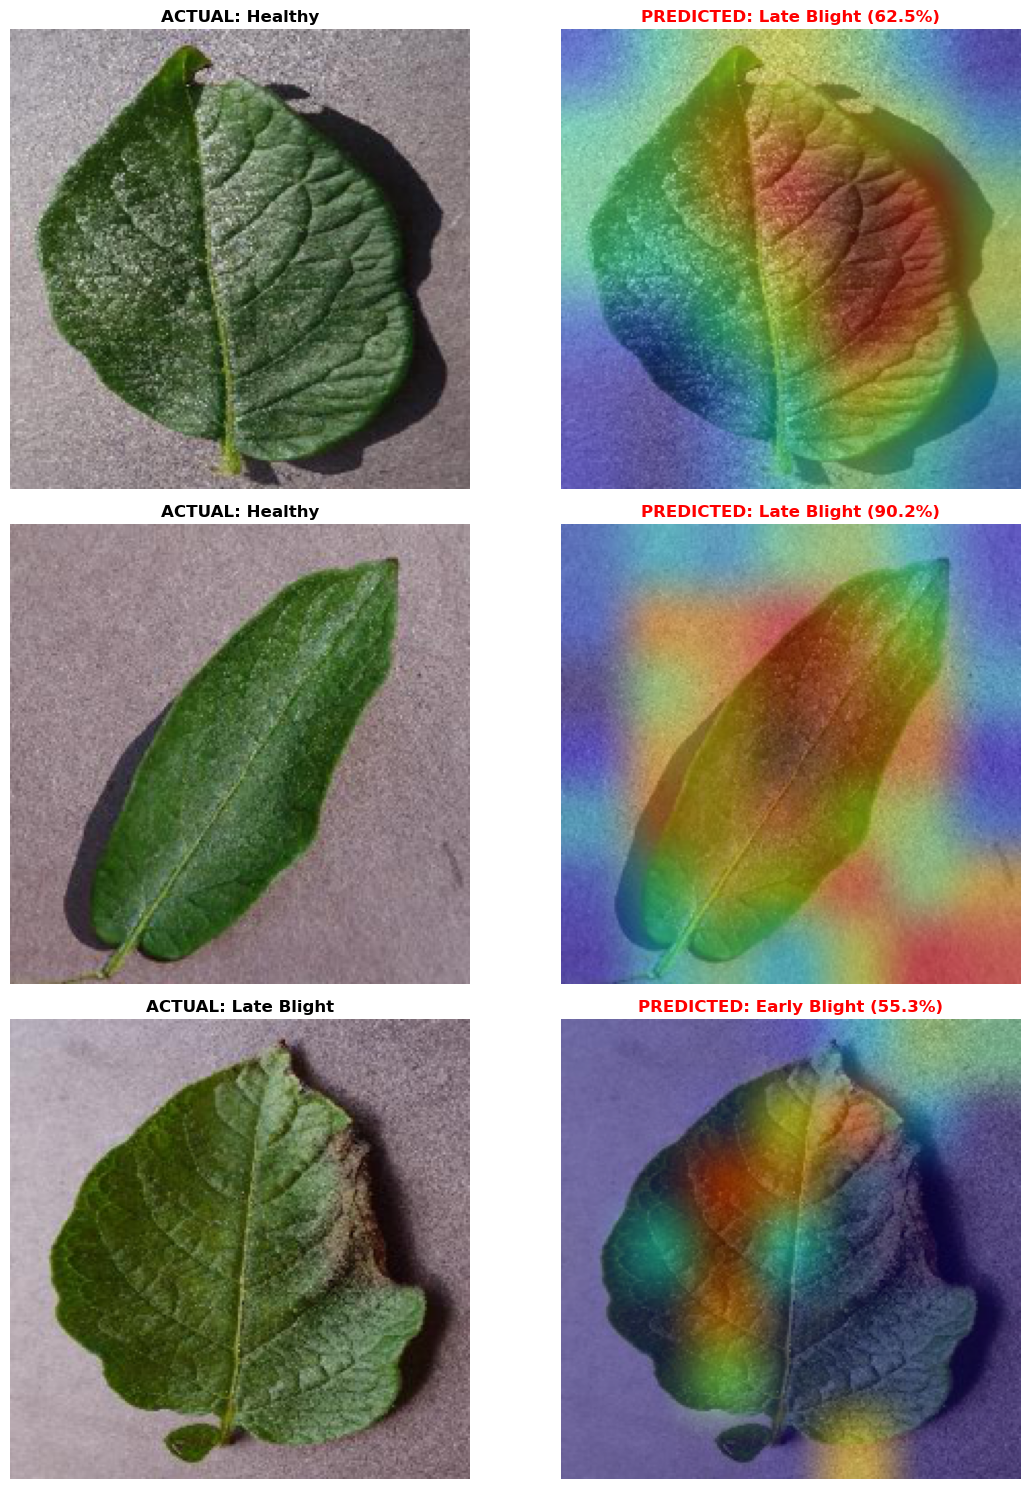

In [ ]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, keras.Model):
            for sub in reversed(layer.layers):
                if isinstance(sub, keras.layers.Conv2D):
                    return layer.name, sub.name
        if isinstance(layer, keras.layers.Conv2D):
            return None, layer.name
    raise ValueError('No Conv2D layer found in model.')

def make_gradcam_heatmap(img_array, model, base_name, last_conv_name):
    if base_name:
        # -- locate the sub-model and its target Conv2D layer
        base_submodel = model.get_layer(base_name)
        conv_layer    = base_submodel.get_layer(last_conv_name)

        # Build an intermediate model: input → (conv_output, base_output)
        base_grad_model = keras.Model(
            inputs=base_submodel.inputs,
            outputs=[conv_layer.output, base_submodel.output]
        )

        with tf.GradientTape() as tape:
            conv_outs, base_out = base_grad_model(img_array, training=False)
            tape.watch(conv_outs)
            # Run the head layers that sit on top of the base sub-model
            x = base_out
            for layer in model.layers:
                # Skip Input and the base sub-model itself; apply the rest
                if isinstance(layer, keras.layers.InputLayer):
                    continue
                if layer.name == base_name:
                    continue
                x = layer(x, training=False)
            preds = x
            pred_idx      = int(tf.argmax(preds[0]))
            class_channel = preds[:, pred_idx]

        grads = tape.gradient(class_channel, conv_outs)
    else:
        # Flat model — Conv2D lives directly in `model`
        grad_model = keras.Model(
            inputs=model.inputs,
            outputs=[model.get_layer(last_conv_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_outs, preds = grad_model(img_array, training=False)
            pred_idx      = int(tf.argmax(preds[0]))
            class_channel = preds[:, pred_idx]
        grads = tape.gradient(class_channel, conv_outs)

    # Pool gradients over spatial dims → weight each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    conf = float(preds[0][pred_idx])
    return heatmap.numpy(), pred_idx, conf

def display_gradcam(img_path, heatmap, alpha=0.4):
    from PIL import Image as PILImage
    img = PILImage.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img_arr = np.array(img, dtype=np.float32)

    heatmap_uint8 = np.uint8(255 * heatmap)
    jet           = cm.get_cmap('jet')
    jet_colors    = jet(np.arange(256))[:, :3]          # (256, 3)
    jet_heatmap   = jet_colors[heatmap_uint8]            # (H, W, 3)  values in [0,1]

    # Resize heatmap to match image
    jet_pil     = PILImage.fromarray(np.uint8(jet_heatmap * 255))
    jet_pil     = jet_pil.resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = np.array(jet_pil, dtype=np.float32)

    superimposed = jet_heatmap * alpha + img_arr * (1 - alpha)
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    return PILImage.fromarray(superimposed)

def analyze_misclassifications(X_test, y_test, model, max_shown=3):
    base_name, last_conv_name = find_last_conv_layer(model)
    errors_found = 0
    plt.figure(figsize=(12, 5 * max_shown))

    for i in range(len(X_test)):
        if errors_found >= max_shown:
            break

        img_path = X_test[i]

        # Preprocess exactly as in load_and_preprocess_image (for inference)
        img_arr  = keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_arr  = keras.preprocessing.image.img_to_array(img_arr)
        img_arr  = tf.keras.applications.mobilenet_v2.preprocess_input(
                       np.expand_dims(img_arr, axis=0))

        heatmap, pred_idx, conf = make_gradcam_heatmap(
            img_arr, model, base_name, last_conv_name)

        if pred_idx != y_test[i]:
            overlay = display_gradcam(img_path, heatmap)

            # Left panel: original image (load without preprocessing for display)
            from PIL import Image as PILImage
            orig = PILImage.open(img_path).resize((IMG_SIZE, IMG_SIZE))

            plt.subplot(max_shown, 2, errors_found * 2 + 1)
            plt.imshow(orig)
            plt.title(f'ACTUAL: {DISPLAY_NAMES[y_test[i]]}', fontweight='bold')
            plt.axis('off')

            plt.subplot(max_shown, 2, errors_found * 2 + 2)
            plt.imshow(overlay)
            plt.title(f'PREDICTED: {DISPLAY_NAMES[pred_idx]} ({conf:.1%})',
                      color='red', fontweight='bold')
            plt.axis('off')

            errors_found += 1

    if errors_found == 0:
        print('No misclassifications found in the selected test range!')

    plt.tight_layout()
    plt.show()

analyze_misclassifications(X_test, y_test, model)


Grad-CAM visualizations were used to interpret how the deep learning model makes predictions on potato leaf images. The heatmap highlights the regions of the image that contributed most strongly to the predicted class, where warmer colors such as red and yellow indicate areas of high importance, while cooler colors such as blue indicate less influence. In correctly classified diseased leaves, the model primarily focused on infected spots, lesions, and discoloration patterns, showing that it learned meaningful disease features rather than relying on irrelevant background information. For healthy leaves, the attention was more evenly distributed across the leaf surface. In some misclassified samples, Grad-CAM revealed that the model focused on shadows, edges, or non-disease regions, suggesting possible confusion caused by image quality, lighting conditions, or visual similarity between diseases. Overall, the Grad-CAM results increase confidence in the model by demonstrating that predictions are generally based on biologically relevant leaf symptoms.

# 5: Evaluation

11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       150
           1       0.93      0.97      0.95       150
           2       0.86      0.78      0.82        23

    accuracy                           0.95       323
   macro avg       0.92      0.90      0.91       323
weighted avg       0.95      0.95      0.95       323



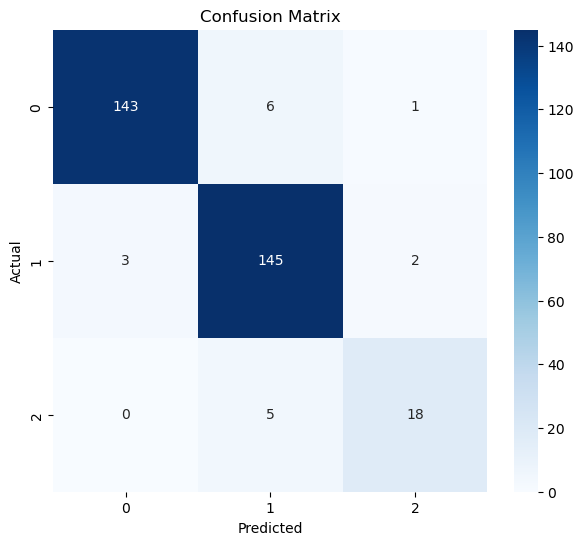

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 766ms/step


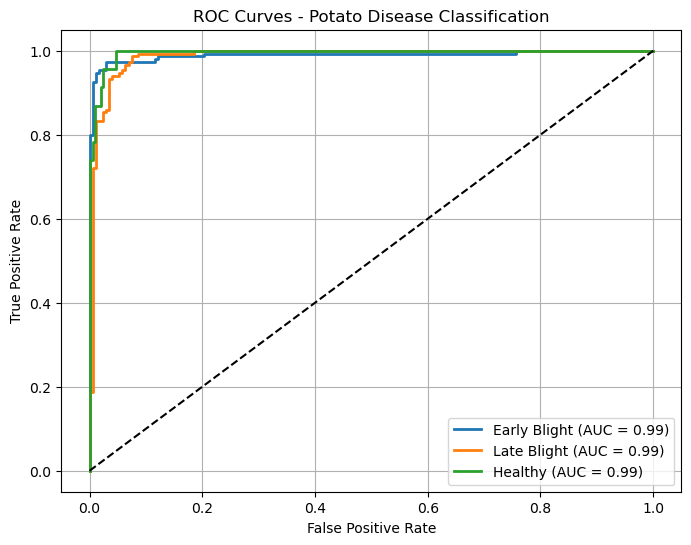

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# True labels
y_true = np.array(y_test)

# Predicted probabilities
y_probs = model.predict(test_ds)

# Convert labels to one-hot
n_classes = 3
y_bin = label_binarize(y_true, classes=[0,1,2])

# Class names
class_names = ['Early Blight', 'Late Blight', 'Healthy']

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Potato Disease Classification")
plt.legend()
plt.grid(True)
plt.show()

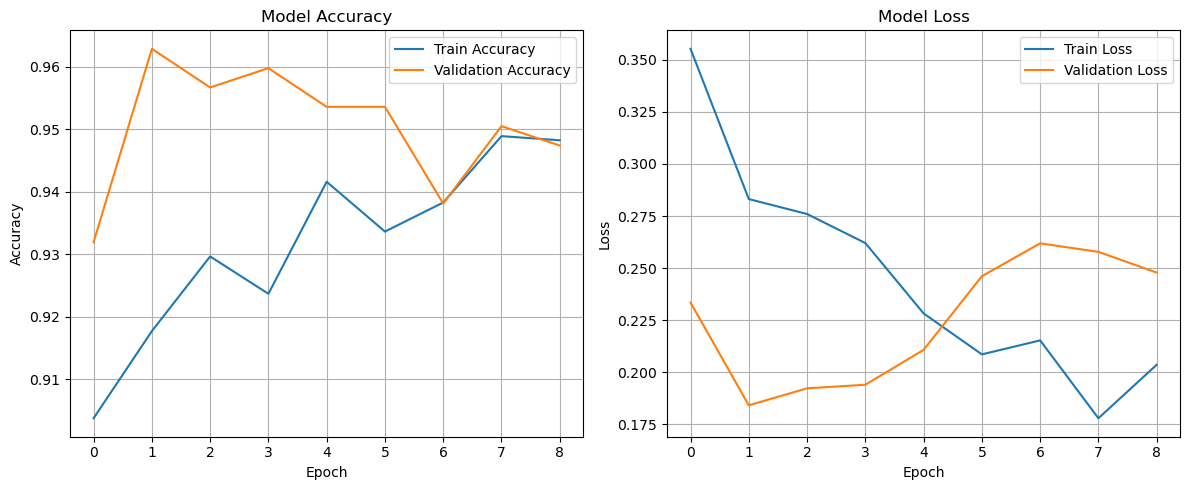

In [31]:

history_dict = history2.history

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()